In [1]:
# Basic imports
import jax.numpy as np
import jax.random as jr
from jax import vmap, jit

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
# Aperture hole coordinates
cens = np.array(
    [
        [0.821457, 2.34684],
        [-2.34960, 1.49034],
        [-2.54456, 2.55259],
        [1.64392, 3.04681],
        [2.73751, -0.321102],
        [1.38503, -3.31443],
        [-3.19337, -1.68413],
        [3.05126, 0.560011],
        [-2.76083, 1.14035],
        [3.02995, -1.91449],
        [0.117786, 3.59025],
        [-0.802156, 3.42140],
        [-1.47228, -3.28982],
        [-1.95968, -0.634178],
        [0.876319, -3.13328],
        [2.01253, -1.55220],
        [-2.07847, -2.57755],
    ]
)

In [3]:
# Generate the full aperture
wf_npix = 1024
diam = 8.2
js = np.arange(1, 22)
aper, basis = dlu.sparse_aperture(wf_npix, diam, cens, 0.45, zernike_nolls=js)
coeffs = 1e-9 * jr.normal(jr.key(0), basis.shape[:2])

# Observational wavelength
wavel = 1e-6
lamd = wavel / diam

# PSF Parameters
psf_pixel_scale = dlu.rad2arcsec(lamd) / 2.5
psf_npix = 128

# Generate the optical system
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diam,
    layers=[
        ("aper", dl.TransmissiveLayer(aper, normalise=True)),
        ("wfe", dl.BasisLayer(basis, coeffs)),
    ],
    psf_npixels=psf_npix,
    psf_pixel_scale=psf_pixel_scale,
)

# Propagate the PSF and get the power spectrum
psf = optics.propagate(wavel)
ps = np.fft.fftshift(np.fft.fft2(psf))

In [13]:
basis.shape

(17, 21, 1024, 1024)

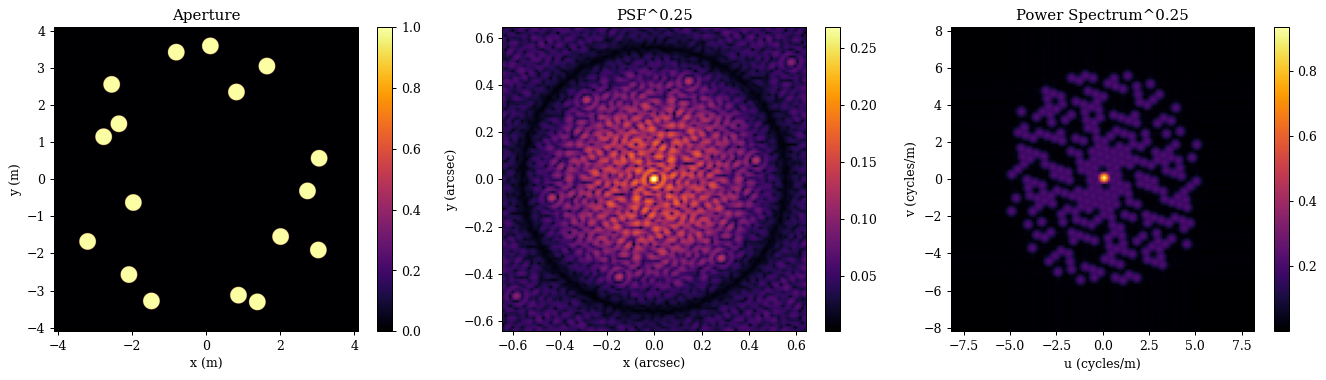

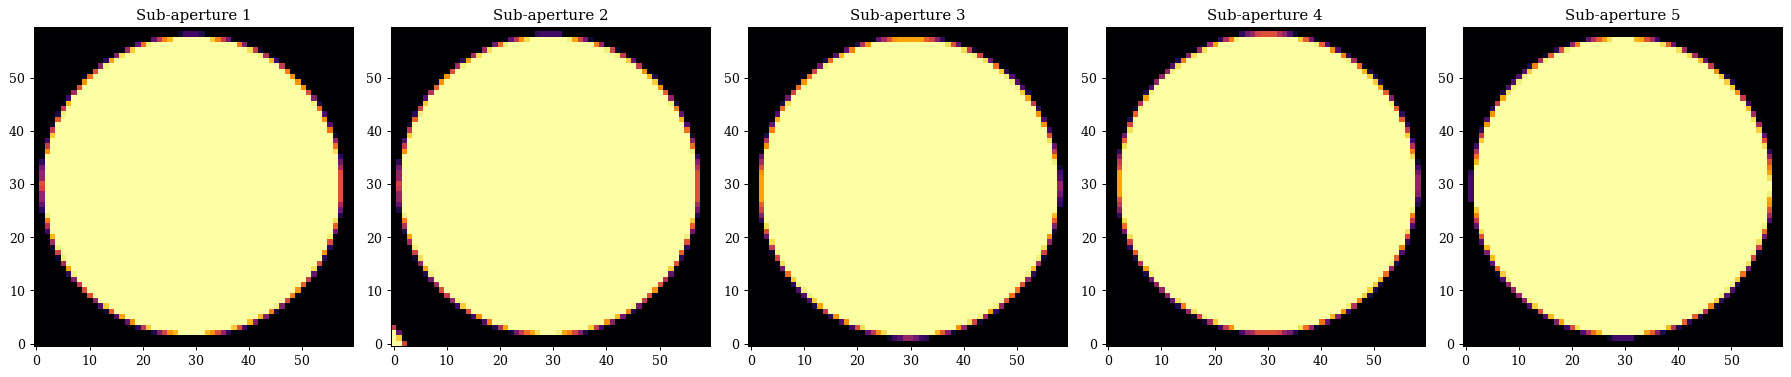

In [4]:
# Plotting function
def cartesian_to_array(xy, npix, diameter):
    """Convert cartesian coordinates to array indices."""
    pixel_scale = diameter / npix
    return np.round(xy / pixel_scale + npix // 2).astype(int)

aper_ext = dlu.imshow_extent(diam)
psf_ext = dlu.imshow_extent(optics.fov)
ps_ext = dlu.imshow_extent(2*diam)

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(aper, extent=aper_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Aperture", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf**0.25, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="PSF^0.25", xlabel="x (arcsec)", ylabel="y (arcsec)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(np.abs(ps) ** 0.5, extent=ps_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Power Spectrum^0.25", xlabel="u (cycles/m)", ylabel="v (cycles/m)")

plt.tight_layout()
plt.show()

s = 30
inds = vmap(cartesian_to_array, (0, None, None))(cens, wf_npix, diam)

plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(f"Sub-aperture {i+1}")
    cj, ci = inds[i]
    plt.imshow(aper[ci - s : ci + s, cj - s : cj + s])
plt.tight_layout()
plt.show()

In [30]:
import abcdLux

# Generate the sparse aperture - we only need a single one!
subap_npix = 128
subap_diam = 0.45
sub_aper, subap_basis = dlu.circular_aperture(subap_npix, subap_diam, zernike_nolls=js)
subap_coeffs = 1e-9 * jr.normal(jr.key(0), (len(cens), len(subap_basis)))

# Normalised subaperture amplitude
subaper_ampl = sub_aper / (np.linalg.norm(np.sqrt(len(cens)) * sub_aper))

# Input coordinates
x_in = dlu.nd_coords(subap_npix, subap_diam / subap_npix)
y_in = dlu.nd_coords(subap_npix, subap_diam / subap_npix)

# Output coordinates
x_out = dlu.nd_coords(psf_npix, dlu.arcsec2rad(psf_pixel_scale))
y_out = dlu.nd_coords(psf_npix, dlu.arcsec2rad(psf_pixel_scale))

# Function to build the OPD over each subaperture
build_opd = vmap(lambda coeffs: dlu.eval_basis(subap_basis, coeffs))

# Basic propagation function for a single subaperture
subap_prop_fn = vmap(
    lambda cen, opd: abcdLux.fraunhofer_prop(
        u_pupil=subaper_ampl * np.exp(1j * dlu.opd2phase(opd, wavel)),
        spec_in=(x_in + cen[0], y_in + cen[1]),
        spec_out=(x_out, y_out),
        lam=wavel,
        f=1,  # Gives pixel scale in radians
    )
)

# Overall propagation function for the sparse aperture
prop_fn = lambda cen, coeffs: np.abs(subap_prop_fn(cen, build_opd(coeffs)).sum(0)) ** 2

# Propagate the PSF and get the power spectrum
psf = prop_fn(cens, subap_coeffs)
ps = np.fft.fftshift(np.fft.fft2(psf))

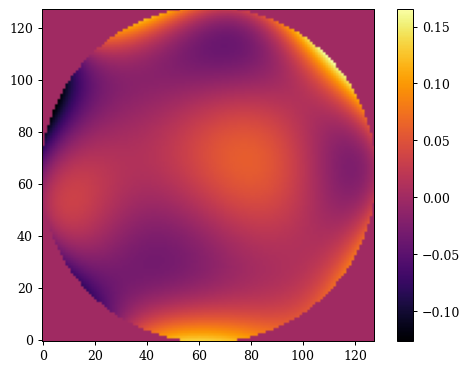

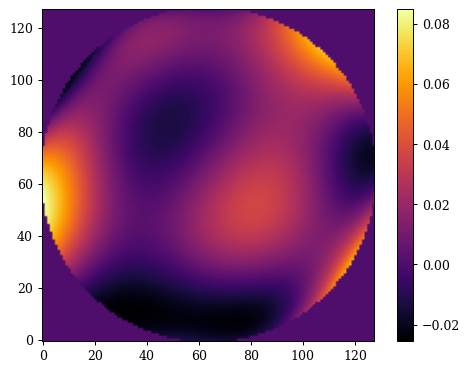

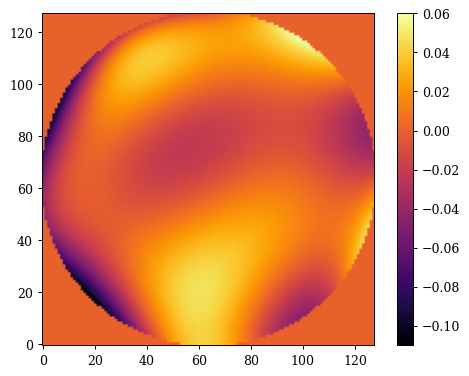

In [41]:
x = subaper_ampl * np.exp(1j * dlu.opd2phase(build_opd(coeffs), wavel))

crop = 0

for i in x[0:3]:
    plt.imshow(np.angle(i))
    # plt.imshow(np.abs(i)[crop:-crop, crop:-crop])
    plt.colorbar()
    plt.show()

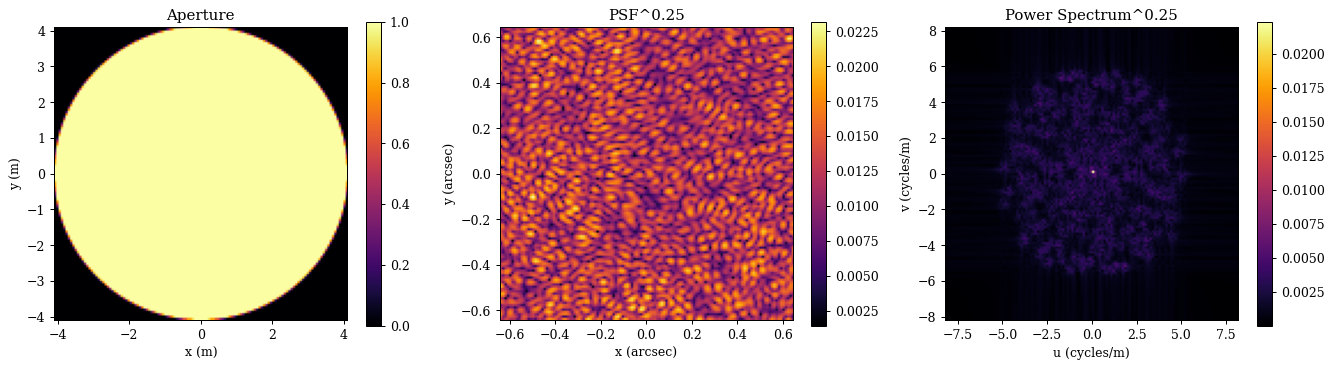

In [29]:
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(sub_aper, extent=aper_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Aperture", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf**0.25, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="PSF^0.25", xlabel="x (arcsec)", ylabel="y (arcsec)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(np.abs(ps) ** 0.5, extent=ps_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Power Spectrum^0.25", xlabel="u (cycles/m)", ylabel="v (cycles/m)")

plt.tight_layout()
plt.show()

In [7]:
# Define the dense and sparse propagation functions with JIT compilation
dense_fn = jit(lambda wl: optics.propagate(wl))
sparse_fn = jit(lambda coeffs: prop_fn(cens, coeffs))

# Compile each of them
_ = dense_fn(wavel)
_ = sparse_fn(subap_coeffs)

In [8]:
%%timeit
_ = dense_fn(wavel).block_until_ready()

1.27 ms ± 63.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [9]:
%%timeit
_ = sparse_fn(subap_coeffs).block_until_ready()

370 μs ± 54.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
